In [9]:
!pip install pandas json tqdm
!pip install google-genai


ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json


In [10]:
import json, re
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# CONFIG
# ============================================================

GENERATION_OUTPUT_PATH = "/kaggle/input/neweval/Finetuned Model Only and with RAGv1.json"
RETRIEVAL_K = 5

VALID_VARIANTS = [
    "model_only",
    "rag_text_reranked",
    "model_only_multimodal",
    "rag_multimodal"
]

# ============================================================
# LOAD DATA
# ============================================================

with open(GENERATION_OUTPUT_PATH, "r") as f:
    raw_data = json.load(f)

data = [
    x for x in raw_data
    if x.get("variant") in VALID_VARIANTS
]

print(f"Evaluating {len(data)} samples")
print("Variants:", sorted(set(x["variant"] for x in data)))

# ============================================================
# TEXT UTILITIES
# ============================================================

def normalize(text):
    return re.sub(r"[^a-z0-9\s]", "", str(text).lower()).strip()

# ============================================================
# RETRIEVAL METRICS ()
# ============================================================

def is_relevant(doc_text, gt_answer):
    """
    Weak relevance:
    - exact containment OR
    - token overlap
    """
    if not doc_text or not gt_answer:
        return False

    doc_n = normalize(doc_text)
    gt_n = normalize(gt_answer)

    if gt_n in doc_n:
        return True

    doc_tokens = set(doc_n.split())
    gt_tokens = set(gt_n.split())

    return len(doc_tokens & gt_tokens) > 0


def precision_at_k(relevance, k):
    return sum(relevance[:k]) / k if relevance else 0.0


def recall_at_k(relevance):
    # QA-style recall: at least one relevant document retrieved
    return 1.0 if any(relevance) else 0.0


def average_precision(relevance):
    score = 0.0
    hits = 0
    for i, rel in enumerate(relevance):
        if rel:
            hits += 1
            score += hits / (i + 1)
    return score / hits if hits > 0 else 0.0

# ============================================================
# RUN AUTOMATIC METRICS (RETRIEVAL ONLY)
# ============================================================

rows = []

for s in tqdm(data, desc="Automatic metrics"):

    # ---------- Retrieval ----------
    retrieved = s.get("retrieved_context", [])[:RETRIEVAL_K]
    gt_answer = s.get("ground_truth_answer", "")

    relevance = [is_relevant(c, gt_answer) for c in retrieved]

    rows.append({
        "id": s["id"],
        "variant": s["variant"],

        # ---- Retrieval quality
        "precision@5": precision_at_k(relevance, RETRIEVAL_K),
        "recall": recall_at_k(relevance),
        "map": average_precision(relevance),
    })

auto_df = pd.DataFrame(rows)

print("=== AUTOMATIC METRICS (MEAN BY VARIANT) ===")
display(auto_df.groupby("variant").mean(numeric_only=True))

Evaluating 106 samples
Variants: ['model_only', 'model_only_multimodal', 'rag_multimodal', 'rag_text_reranked']


Automatic metrics: 100%|██████████| 106/106 [00:00<00:00, 1652.78it/s]

=== AUTOMATIC METRICS (MEAN BY VARIANT) ===


,precision@5,recall,map
variant,,,
model_only,0.000000,0.000000,0.000000
model_only_multimodal,0.000000,0.000000,0.000000
rag_multimodal,0.600000,0.826087,0.673068
rag_text_reranked,0.613333,0.833333,0.641343


In [11]:
import time
import numpy as np
import pandas as pd
from tqdm import tqdm

import google.generativeai as genai
from kaggle_secrets import UserSecretsClient

# ============================================================
# CONFIG
# ============================================================

VALID_VARIANTS = [
    "model_only",
    "rag_text_reranked",
    "model_only_multimodal",
    "rag_multimodal"
]

# ============================================================
# SETUP JUDGE (DETERMINISTIC)
# ============================================================

secrets = UserSecretsClient()
genai.configure(api_key=secrets.get_secret("gemini_api"))

judge = genai.GenerativeModel(
    "gemini-2.5-flash",
    generation_config={"temperature": 0.1}
)

# ============================================================
# JUDGE FUNCTION
# ============================================================

def judge_diagnosis_correctness(sample):
    """
    Binary medical correctness judgment.
    1 = correct / clinically equivalent
    0 = incorrect
    """

    prompt = f"""
You are a medical expert.

Is the predicted diagnosis medically correct or clinically equivalent
to the ground-truth diagnosis?

Predicted diagnosis:
{sample['pred_answer']}

Ground-truth diagnosis:
{sample['ground_truth_answer']}

Answer ONLY with:
y = correct or clinically equivalent
n = incorrect
"""

    try:
        resp = judge.generate_content(prompt)
        ans = resp.text.strip().lower()

        if ans.startswith("y"):
            return 1
        elif ans.startswith("n"):
            return 0
        else:
            return np.nan

    except Exception as e:
        print("[LLM ERROR]", e)
        return np.nan

# ============================================================
# RUN EVALUATION
# ============================================================

rows = []

for s in tqdm(data, desc="Diagnosis correctness (LLM-as-judge)"):

    if s.get("variant") not in VALID_VARIANTS:
        continue

    rows.append({
        "id": s["id"],
        "variant": s["variant"],
        "diagnosis_correct_llm": judge_diagnosis_correctness(s)
    })

    time.sleep(1)  # rate-limit safety

df_dx = pd.DataFrame(rows)

print("=== DIAGNOSIS CORRECTNESS (LLM AS JUDGE) ===")
display(df_dx.groupby("variant").mean(numeric_only=True))


Diagnosis correctness (LLM-as-judge): 100%|██████████| 106/106 [11:33<00:00,  6.54s/it] 

=== DIAGNOSIS CORRECTNESS (LLM AS JUDGE) ===


,diagnosis_correct_llm
variant,
model_only,0.166667
model_only_multimodal,0.652174
rag_multimodal,0.521739
rag_text_reranked,0.200000


In [12]:
# ============================================================
# META-RAG FACTOID-LEVEL FAITHFULNESS & HALLUCINATION (CLINICAL)
# VeriFact-style verification + MetaRAG decomposition
# ============================================================

import json, re, time
import numpy as np
import pandas as pd
from tqdm import tqdm

import google.generativeai as genai
from kaggle_secrets import UserSecretsClient

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

VALID_VARIANTS = [
    "model_only",
    "rag_text_reranked",
    "model_only_multimodal",
    "rag_multimodal"
]

# ------------------------------------------------------------
# 🔑 Initialize LLM Judge (CLINICAL, LOOSE ENTAILMENT)
# ------------------------------------------------------------

secrets = UserSecretsClient()
genai.configure(api_key=secrets.get_secret("gemini_api"))

judge = genai.GenerativeModel(
    "gemini-2.5-flash",
    generation_config={"temperature": 0.1}
)

# ------------------------------------------------------------
# Helper: full raw answer (diagnosis + reasoning)
# ------------------------------------------------------------

def get_full_answer(sample):
    return (
        "Diagnosis:\n" + sample.get("pred_answer", "") +
        "\n\nClinical Reasoning:\n" + sample.get("pred_clinical_rationale", "")
    ).strip()

# ------------------------------------------------------------
# Safe LLM call wrapper
# ------------------------------------------------------------

def safe_generate(prompt, sleep=0.5):
    try:
        resp = judge.generate_content(prompt)
        time.sleep(sleep)
        return resp.text
    except Exception as e:
        print("[LLM ERROR]", e)
        return ""

# ============================================================
# A.1 FACTOID DECOMPOSITION (EXACT METARAG PROMPT)
# ============================================================

def extract_factoids(answer):
    prompt = f"""
You are a fact extraction assistant.
Your task is to extract all specific factual propositions from the given text.

Instructions:
1. Extract every distinct factual statement present in the input, even if the statement is incorrect,
ambiguous, or nonsensical.
2. Each extracted proposition must be a complete, standalone sentence.
3. Each sentence must express only one atomic fact.
4. If a sentence contains multiple facts, split them into multiple atomic fact sentences.
5. Do not paraphrase, rewrite, summarize, interpret, infer, or judge any part of the input.
6. Do not omit or correct any statements, regardless of their factual accuracy.
7. Output your answer as a JSON array of strings.

Now, extract atomic facts from this text:
Input:
{answer}
"""

    text = safe_generate(prompt)
    blocks = re.findall(r"\[.*?\]", text, re.S)

    if not blocks:
        return []

    try:
        return json.loads(blocks[0])
    except Exception:
        return []

# ============================================================
# CLINICAL FACTOID VERIFICATION (VERIFACT-STYLE)
# ============================================================

def verify_factoid(statement, context):
    """
    Returns one of:
    - SUPPORTED
    - CONTRADICTED
    - NOT FOUND
    """

    prompt = f"""
You are a clinical expert verifying a medical claim against reference clinical text.

Judge the claim as:
- SUPPORTED: clearly supported or clinically implied by the reference
- CONTRADICTED: clearly false or inconsistent with the reference
- NOT FOUND: not mentioned or cannot be determined

Clinical guidance:
- Clinical implication and synonymous phrasing count as SUPPORTED.
- Absence of evidence does NOT imply falsehood.
- Only mark CONTRADICTED if there is a clear conflict.

Reference text:
{context}

Claim:
{statement}

Return ONLY one label:
SUPPORTED
CONTRADICTED
NOT FOUND
"""

    text = safe_generate(prompt).strip().upper()

    for lbl in ["SUPPORTED", "CONTRADICTED", "NOT FOUND"]:
        if lbl in text:
            return lbl

    return "NOT FOUND"

# ============================================================
# META-RAG / VERIFACT HYBRID SCORING
# ============================================================

def metarag_proxy(sample):

    # ❗ Faithfulness undefined without retrieval
    if sample["variant"] in ["model_only", "model_only_multimodal"]:
        return {
            "faithfulness": np.nan,
            "hallucination": np.nan,
            "num_factoids": 0
        }

    context = "\n".join(sample.get("retrieved_context", []))[:3000]
    answer = get_full_answer(sample)

    factoids = extract_factoids(answer)

    if not factoids:
        return {
            "faithfulness": np.nan,
            "hallucination": np.nan,
            "num_factoids": 0
        }

    penalties = []

    for fact in factoids:
        decision = verify_factoid(fact, context)

        if decision == "SUPPORTED":
            penalties.append(0.0)
        elif decision == "CONTRADICTED":
            penalties.append(1.0)
        else:
            pass  # NOT FOUND → excluded (VeriFact-style)

    if not penalties:
        return {
            "faithfulness": np.nan,
            "hallucination": np.nan,
            "num_factoids": len(factoids)
        }

    hallucination = float(np.mean(penalties))
    faithfulness = 1.0 - hallucination

    return {
        "faithfulness": faithfulness,
        "hallucination": hallucination,
        "num_factoids": len(factoids)
    }

# ============================================================
# RUN META-RAG / VERIFACT EVALUATION
# ============================================================

rows = []

for s in tqdm(data, desc="MetaRAG (Clinical VeriFact)"):
    if s["variant"] not in VALID_VARIANTS:
        continue

    scores = metarag_proxy(s)

    rows.append({
        "id": s["id"],
        "variant": s["variant"],
        **scores
    })

    time.sleep(0.5)

df_metarag = pd.DataFrame(rows)

print("\n=== META-RAG / VERIFACT FACTOID-LEVEL SCORES ===\n")
display(df_metarag.groupby("variant").mean(numeric_only=True))


MetaRAG (Clinical VeriFact): 100%|██████████| 106/106 [54:38<00:00, 30.93s/it] 


=== META-RAG / VERIFACT FACTOID-LEVEL SCORES ===




/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,faithfulness,hallucination,num_factoids
variant,,,
model_only,NaN,NaN,0.000000
model_only_multimodal,NaN,NaN,0.000000
rag_multimodal,0.371863,0.628137,18.739130
rag_text_reranked,0.519696,0.480304,17.266667


In [13]:
# ============================================================
# CELL — MEDCASEREASONING REASONING RECALL (EXACT IMPLEMENTATION)
# ============================================================

import json, re, time
import numpy as np
import pandas as pd
from tqdm import tqdm

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

VALID_VARIANTS = [
    "model_only",
    "rag_text_reranked",
    "model_only_multimodal",
    "rag_multimodal"
]

# ------------------------------------------------------------
# LLM JUDGE: MEDCASEREASONING MATCHING (NO SCORING)
# ------------------------------------------------------------

def judge_medcase_reasoning(sample):
    """
    Returns:
      {
        "matching_dict": {
            "1": [...],
            "2": [...],
            ...
        }
      }
    """

    prompt = f"""
You are an experienced medical expert tasked with comparing diagnostic reasoning statements that support a given
diagnosis for a given patient case.

Your goal is to find supporting statements in the predicted diagnostic reasons that match the groundtruth
diagnostic reasons.

For each of the statements in Groundtruth Diagnostic Reasons, you need to find the statement or statements in the
Predicted Diagnostic Reasons that state the equivalent justification for the diagnosis.

For instance, if the groundtruth diagnostic reason is "The patient has a fever", and the predicted diagnostic
reason is "The patient has a fever due to a viral infection", then this is a match.
If the groundtruth diagnostic reason is "The patient has a fever", and the predicted diagnostic reason is "The
patient has a sore throat", then this is not a match.

Instructions:
1. Analyze each statement in Groundtruth Diagnostic Reasons.
2. For each statement in Groundtruth Diagnostic Reasons, find any matching statements in Predicted Diagnostic
Reasons.
3. Create a JSON object with the following structure:
- The main key should be "matching_dict"
- Each key within "matching_dict" should be a number representing a statement from Groundtruth Diagnostic
Reasons
- The value for each key should be a list of matching statements from Predicted Diagnostic Reasons
- If there are no matches for a statement, use an empty array

Before providing your final output, wrap your analysis inside <diagnostic_comparison> tags:
1. List all statements from Groundtruth Diagnostic Reasons and Predicted Diagnostic Reasons.
2. For each statement in Groundtruth Diagnostic Reasons, consider potential matches from Predicted Diagnostic
Reasons:
- List pros and cons for each potential match
3. Summarize your final matching decisions

4. In the JSON output, only include the statements that are in the Predicted Diagnostic Reasons.
5. The statements must appear exactly as they are in the Predicted Diagnostic Reasons, verbatim.

Wrap your JSON output in ```json tags.

----------------------------------------
GROUNDTRUTH DIAGNOSTIC REASONS
----------------------------------------
{sample['ground_truth_clinical_rationale']}

----------------------------------------
PREDICTED DIAGNOSTIC REASONS
----------------------------------------
{sample['pred_clinical_rationale']}
"""

    try:
        # ✅ FIX 1: Explicitly disable safety filters to prevent blocking medical content
        # Note: 'judge' must be your GenerativeModel instance
        resp = judge.generate_content(
            prompt,
            safety_settings={
                'HATE': 'BLOCK_NONE',
                'HARASSMENT': 'BLOCK_NONE',
                'SEXUAL': 'BLOCK_NONE',
                'DANGEROUS': 'BLOCK_NONE'
            }
        )
        
        # ✅ FIX 2: Verify candidate and parts exist before calling .text
        if not (resp.candidates and resp.candidates[0].content.parts):
            print(f"[MedCaseReasoning BLOCKED] {sample['id']} - Reason: {resp.candidates[0].finish_reason}")
            return {"matching_dict": {}}

        text = resp.text.strip()

        # ✅ STRICT JSON-FENCE PARSING
        json_blocks = re.findall(r"```json\s*(\{.*?\})\s*```", text, re.S)

        if len(json_blocks) != 1:
            raise ValueError("Expected exactly one JSON block")

        parsed = json.loads(json_blocks[0])

        # ✅ HARD VALIDATION
        if "matching_dict" not in parsed or not isinstance(parsed["matching_dict"], dict):
            raise ValueError("Invalid MedCaseReasoning JSON structure")

        return parsed

    except Exception as e:
        print(f"[MedCaseReasoning ERROR] {sample['id']}")
        print("Error:", e)
        # Handle cases where resp might not be defined or text might still be inaccessible
        try:
            raw_out = resp.text if (resp and resp.candidates and resp.candidates[0].content.parts) else "NO RESPONSE"
        except:
            raw_out = "INACCESSIBLE"
        print("Raw output:", raw_out)
        return {"matching_dict": {}}


# ------------------------------------------------------------
# REASONING RECALL COMPUTATION (PAPER-DEFINITION EXACT)
# ------------------------------------------------------------

rows = []

for s in tqdm(data, desc="MedCaseReasoning → Reasoning Recall"):

    if s["variant"] not in VALID_VARIANTS:
        continue

    out = judge_medcase_reasoning(s)
    matching_dict = out.get("matching_dict", {})

    if not matching_dict:
        recall = 0.0
        total_gt = 0
        matched = 0
    else:
        total_gt = len(matching_dict)
        matched = sum(
            1 for k, v in matching_dict.items()
            if isinstance(v, list) and len(v) > 0
        )
        recall = matched / total_gt if total_gt > 0 else 0.0

    rows.append({
        "id": s["id"],
        "variant": s["variant"],
        "num_groundtruth_reasons": total_gt,
        "num_matched_reasons": matched,
        "reasoning_recall": recall
    })

    time.sleep(1)

df_rr = pd.DataFrame(rows)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n=== MEAN REASONING RECALL BY VARIANT ===\n")
display(df_rr.groupby("variant").mean(numeric_only=True))

print("\n=== SAMPLE ROWS ===\n")
display(df_rr.head())


MedCaseReasoning → Reasoning Recall: 100%|██████████| 106/106 [47:25<00:00, 26.84s/it]


=== MEAN REASONING RECALL BY VARIANT ===



,num_groundtruth_reasons,num_matched_reasons,reasoning_recall
variant,,,
model_only,6.900000,4.133333,0.638148
model_only_multimodal,7.565217,5.000000,0.674724
rag_multimodal,7.695652,4.217391,0.602457
rag_text_reranked,7.100000,3.333333,0.532217



=== SAMPLE ROWS ===



,id,variant,num_groundtruth_reasons,num_matched_reasons,reasoning_recall
0,CHAPTER_III_TheTrypanosomiases.json_model_only,model_only,3,3,1.000000
1,CHAPTER_III_TheTrypanosomiases.json_model_only...,model_only_multimodal,3,3,1.000000
2,CHAPTER_III_TheTrypanosomiases.json_rag_text,rag_text_reranked,11,8,0.727273
3,CHAPTER_III_TheTrypanosomiases.json_rag_multim...,rag_multimodal,3,3,1.000000
4,CHAPTER_II_BlackwaterFever.json_model_only,model_only,3,2,0.666667


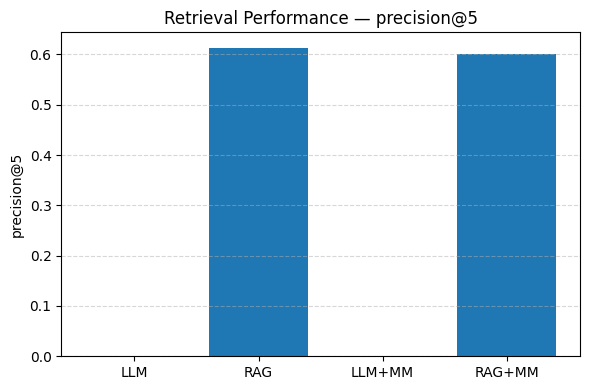

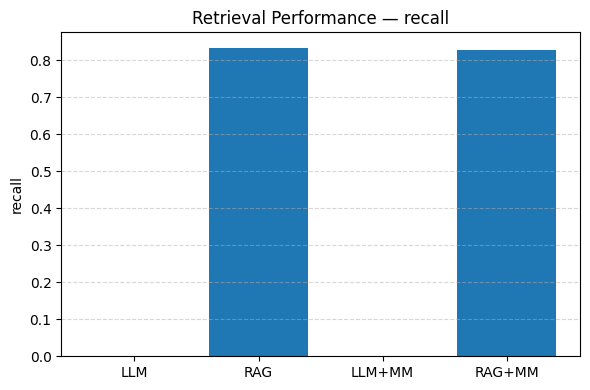

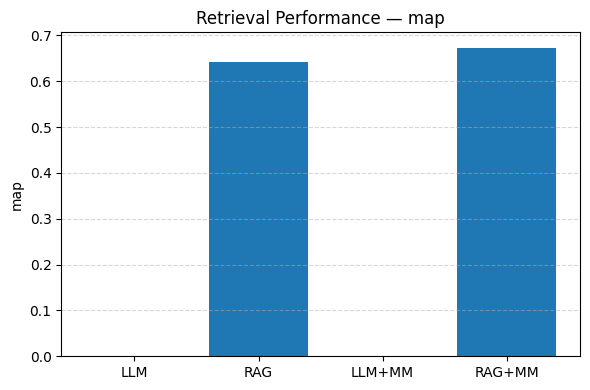

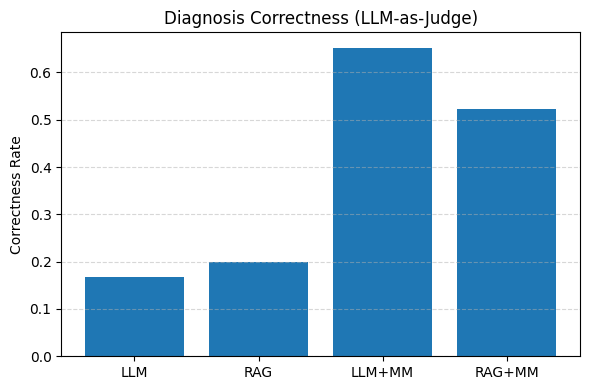

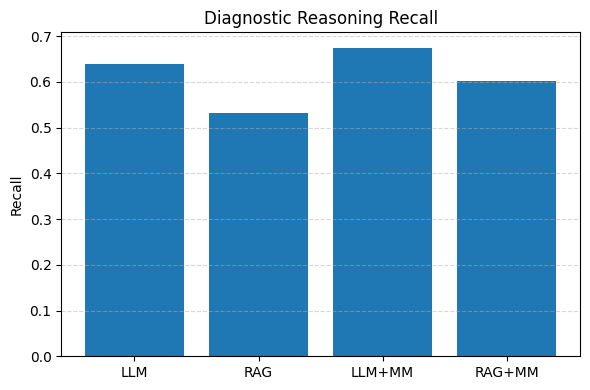

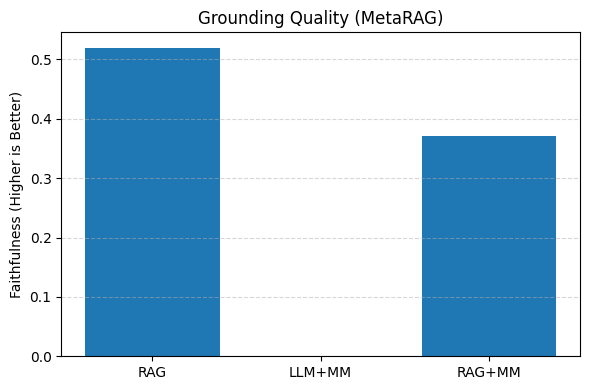

In [14]:
# ============================================================
# VISUALIZATION — RAG EFFECTIVENESS BY STAGE (FIXED LABELS)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Variant label mapping
# -----------------------------

VARIANT_LABELS = {
    "model_only": "LLM",
    "rag_text_reranked": "RAG",
    "model_only_multimodal": "LLM+MM",
    "rag_multimodal": "RAG+MM"
}

VARIANT_ORDER = [
    "model_only",
    "rag_text_reranked",
    "model_only_multimodal",
    "rag_multimodal"
]

# -----------------------------
# Helper: bar plot (publication-safe)
# -----------------------------

def plot_bar(df, metric, title, ylabel, invert=False):

    means = (
        df.groupby("variant")[metric]
        .mean()
        .reindex(VARIANT_ORDER)
    )

    if invert:
        means = 1 - means

    labels = [VARIANT_LABELS.get(v, v) for v in means.index]

    plt.figure(figsize=(6,4))
    plt.bar(labels, means.values)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# ============================================================
# 1️⃣ RETRIEVAL QUALITY
# ============================================================

for metric in ["precision@5", "recall", "map"]:
    plot_bar(
        auto_df,
        metric,
        title=f"Retrieval Performance — {metric}",
        ylabel=metric
    )


# ============================================================
# 2️⃣ DIAGNOSIS CORRECTNESS (LLM-AS-JUDGE)
# ============================================================

plot_bar(
    df_dx,
    "diagnosis_correct_llm",
    title="Diagnosis Correctness (LLM-as-Judge)",
    ylabel="Correctness Rate"
)


# ============================================================
# 3️⃣ REASONING QUALITY (MEDCASEREASONING)
# ============================================================

plot_bar(
    df_rr,
    "reasoning_recall",
    title="Diagnostic Reasoning Recall",
    ylabel="Recall"
)


# ============================================================
# 4️⃣ GROUNDING QUALITY (META-RAG / VERIFACT)
# ============================================================

plot_bar(
    df_metarag,
    "faithfulness",
    title="Grounding Quality (MetaRAG)",
    ylabel="Faithfulness (Higher is Better)"
)
